In [27]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("fraud_oracle.csv")

# Make a working copy
df_clean = df.copy()

# -----------------------------
# 1) Fix invalid placeholders
# -----------------------------

# DayOfWeekClaimed: "0" is not a valid day, so convert to "Unknown"
df_clean["DayOfWeekClaimed"] = df_clean["DayOfWeekClaimed"].replace("0", "Unknown")

# MonthClaimed: "0" is not a valid month, so convert to "Unknown"
df_clean["MonthClaimed"] = df_clean["MonthClaimed"].replace("0", "Unknown")

# Keep "none" in these columns as a valid category
# No replacement needed, but we leave comments here for documentation
# df_clean["Days_Policy_Accident"] -> keep "none"
# df_clean["Days_Policy_Claim"] -> keep "none"


# -----------------------------
# 2) Fix Age = 0
# -----------------------------
# Age = 0 is unrealistic, so replace with missing first
df_clean["Age"] = df_clean["Age"].replace(0, np.nan)

# Create midpoint mapping based on AgeOfPolicyHolder bands
age_band_midpoint = {
    "16 to 17": 16.5,
    "18 to 20": 19,
    "21 to 25": 23,
    "26 to 30": 28,
    "31 to 35": 33,
    "36 to 40": 38,
    "41 to 50": 45.5,
    "51 to 65": 58,
    "over 65": 70
}

# Impute missing Age using AgeOfPolicyHolder midpoint
df_clean["Age"] = df_clean.apply(
    lambda row: age_band_midpoint.get(row["AgeOfPolicyHolder"], np.nan)
    if pd.isna(row["Age"]) else row["Age"],
    axis=1
)

# Fallback: if any Age is still missing, fill with median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())


# -----------------------------
# 3) Optional: drop ID column
# -----------------------------
# Recommended for modelling, because PolicyNumber is only an identifier
df_clean = df_clean.drop(columns=["PolicyNumber"])


# -----------------------------
# 4) Quick validation checks
# -----------------------------
print("Remaining Age = 0 count:", (df_clean["Age"] == 0).sum())
print("Remaining missing Age count:", df_clean["Age"].isna().sum())
print("DayOfWeekClaimed unique values:", df_clean["DayOfWeekClaimed"].unique())
print("MonthClaimed unique values:", df_clean["MonthClaimed"].unique())
print("Days_Policy_Accident unique values:", df_clean["Days_Policy_Accident"].unique())
print("Days_Policy_Claim unique values:", df_clean["Days_Policy_Claim"].unique())

# Save cleaned file if needed
df_clean.to_csv("fraud_oracle_cleaned.csv", index=False)
print("Cleaned file saved as fraud_oracle_cleaned.csv")

Remaining Age = 0 count: 0
Remaining missing Age count: 0
DayOfWeekClaimed unique values: ['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday'
 'Unknown']
MonthClaimed unique values: ['Jan' 'Nov' 'Jul' 'Feb' 'Mar' 'Dec' 'Apr' 'Aug' 'May' 'Jun' 'Sep' 'Oct'
 'Unknown']
Days_Policy_Accident unique values: ['more than 30' '15 to 30' 'none' '1 to 7' '8 to 15']
Days_Policy_Claim unique values: ['more than 30' '15 to 30' '8 to 15' 'none']
Cleaned file saved as fraud_oracle_cleaned.csv


In [3]:
pd.set_option('display.max_columns', None)

In [7]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [17]:
with pd.option_context('display.max_rows', None):
    print(df['Deductible'].value_counts().sort_index(ascending=False))

Deductible
700      311
500      263
400    14838
300        8
Name: count, dtype: int64


In [13]:
df

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,35,Policy Holder,Sedan - Collision,Sedan,20000 to 29000,1,15416,5,400,4,more than 30,more than 30,2 to 4,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,30,Policy Holder,Sedan - Liability,Sport,30000 to 39000,0,15417,11,400,3,more than 30,more than 30,more than 4,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,24,Policy Holder,Sedan - Collision,Sedan,20000 to 29000,1,15418,4,400,4,more than 30,more than 30,more than 4,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,34,Third Party,Sedan - All Perils,Sedan,20000 to 29000,0,15419,6,400,4,more than 30,more than 30,none,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


In [12]:
with pd.option_context('display.max_rows', None):
    print(df['Age'].value_counts().sort_index(ascending=False))

Age
80     32
79     20
78     35
77     29
76     42
75     34
74     35
73     32
72     45
71     40
70     27
69     32
68     32
67     31
66     42
65    135
64    146
63    136
62    112
61    145
60    156
59    138
58    134
57    144
56    146
55    282
54    288
53    253
52    276
51    279
50    290
49    265
48    291
47    308
46    296
45    386
44    411
43    404
42    401
41    423
40    383
39    435
38    384
37    410
36    406
35    569
34    573
33    574
32    544
31    550
30    596
29    552
28    560
27    540
26    535
25    104
24    135
23    122
22    125
21    127
20     28
19     32
18     48
17      6
16      9
0     320
Name: count, dtype: int64


In [18]:
with pd.option_context('display.max_rows', None):
    print(df['FraudFound_P'].value_counts().sort_index(ascending=False))

FraudFound_P
1      923
0    14497
Name: count, dtype: int64


In [5]:
df.isna().sum().sum()

np.int64(0)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("fraud_oracle.csv")
print("Original shape:", df.shape)

# =========================
# 2. CLEANING
# =========================
df_clean = df.copy()

# Recode invalid placeholders
df_clean["DayOfWeekClaimed"] = df_clean["DayOfWeekClaimed"].replace("0", "Unknown")
df_clean["MonthClaimed"] = df_clean["MonthClaimed"].replace("0", "Unknown")

# Keep "none" as category in these columns
# No replacement needed:
# df_clean["Days_Policy_Accident"]
# df_clean["Days_Policy_Claim"]

# Treat Age = 0 as invalid
df_clean["Age"] = df_clean["Age"].replace(0, np.nan)

# Impute Age using AgeOfPolicyHolder midpoint
age_band_midpoint = {
    "16 to 17": 16.5,
    "18 to 20": 19,
    "21 to 25": 23,
    "26 to 30": 28,
    "31 to 35": 33,
    "36 to 40": 38,
    "41 to 50": 45.5,
    "51 to 65": 58,
    "over 65": 70
}

df_clean["Age"] = df_clean.apply(
    lambda row: age_band_midpoint.get(row["AgeOfPolicyHolder"], np.nan)
    if pd.isna(row["Age"]) else row["Age"],
    axis=1
)

# Fallback median imputation
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Drop ID column
df_clean = df_clean.drop(columns=["PolicyNumber"])

print("Cleaned shape:", df_clean.shape)
print("Remaining Age = 0:", (df_clean["Age"] == 0).sum())
print("Remaining missing Age:", df_clean["Age"].isna().sum())


Original shape: (15420, 33)
Cleaned shape: (15420, 32)
Remaining Age = 0: 0
Remaining missing Age: 0


Feature-engineered shape: (15420, 37)

Target distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Target percentage:
FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64


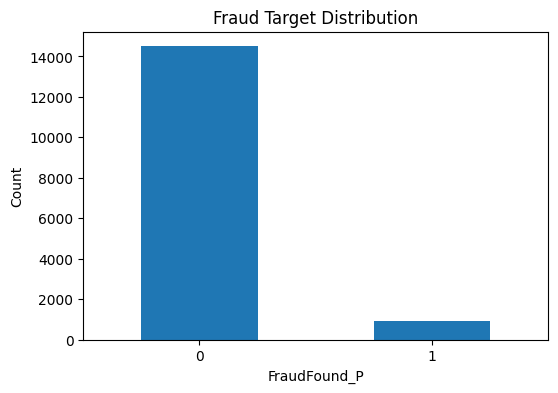


Fraud rate by Fault:
                   mean  count
Fault                         
Policy Holder  7.889581  11230
Third Party    0.883055   4190

Fraud rate by BasePolicy:
                 mean  count
BasePolicy                  
All Perils  10.159586   4449
Collision    7.296209   5962
Liability    0.718706   5009

Fraud rate by VehicleCategory:
                      mean  count
VehicleCategory                  
Utility          11.253197    391
Sedan             8.220453   9671
Sport             1.567749   5358

Fraud rate by AccidentArea:
                  mean  count
AccidentArea                 
Rural         8.322904   1598
Urban         5.715526  13822

Fraud rate by AddressChange_Claim:
                          mean  count
AddressChange_Claim                  
under 6 months       75.000000      4
2 to 3 years         17.525773    291
1 year                6.470588    170
no change             5.759564  14324
4 to 8 years          5.229794    631


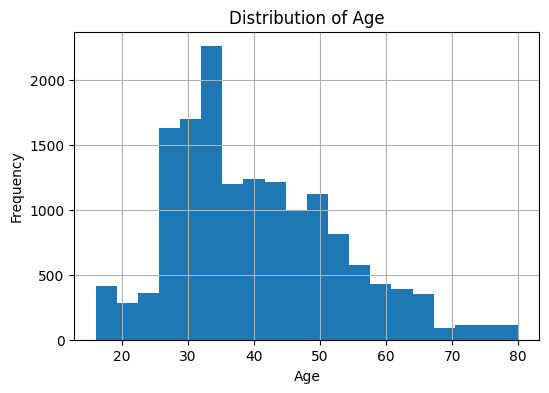

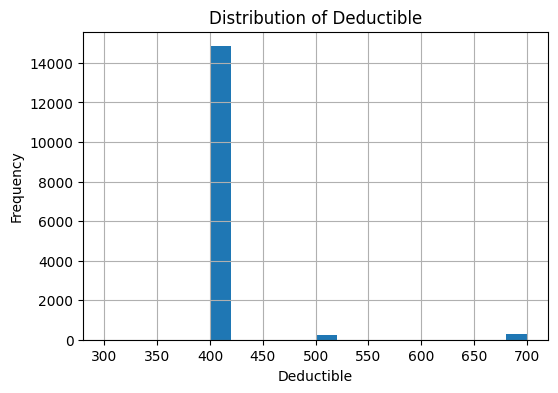

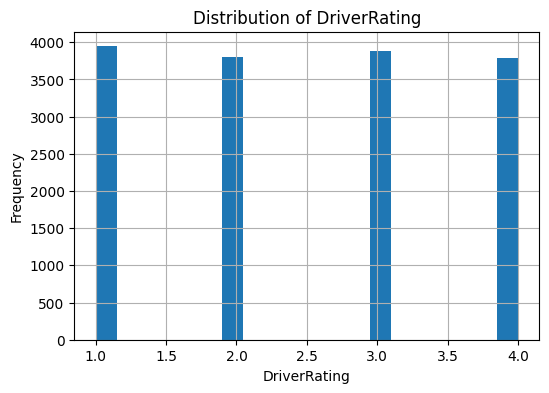

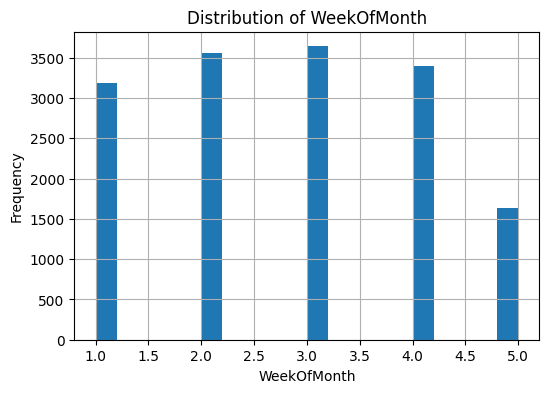

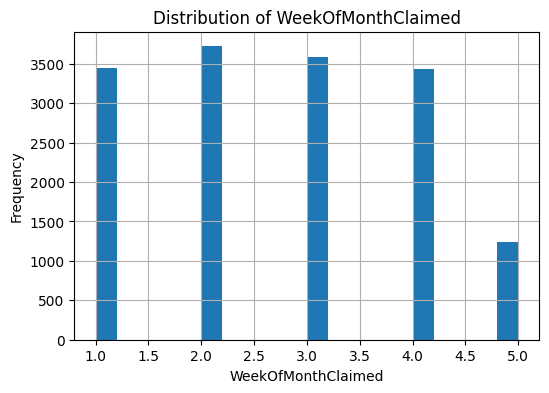

In [16]:
# =========================
# 3. DOMAIN-DERIVED FEATURES
# =========================
df_fe = df_clean.copy()

df_fe["HasPoliceReport"] = df_fe["PoliceReportFiled"].map({"Yes": 1, "No": 0})
df_fe["HasWitness"] = df_fe["WitnessPresent"].map({"Yes": 1, "No": 0})

high_price_bands = ["60000 to 69000", "more than 69000"]
df_fe["HighVehiclePrice"] = df_fe["VehiclePrice"].isin(high_price_bands).astype(int)

recent_address_bands = ["under 6 months", "1 year"]
df_fe["RecentAddressChange"] = df_fe["AddressChange_Claim"].isin(recent_address_bands).astype(int)

short_policy_accident_bands = ["1 to 7", "8 to 15", "15 to 30"]
df_fe["ShortPolicyToAccident"] = df_fe["Days_Policy_Accident"].isin(short_policy_accident_bands).astype(int)

print("Feature-engineered shape:", df_fe.shape)

# =========================
# 4. APPLIED EDA
# =========================
target = "FraudFound_P"

# Target distribution
print("\nTarget distribution:")
print(df_fe[target].value_counts())
print("\nTarget percentage:")
print(df_fe[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
df_fe[target].value_counts().sort_index().plot(kind="bar")
plt.title("Fraud Target Distribution")
plt.xlabel("FraudFound_P")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Fraud rate by key variables
eda_cols = ["Fault", "BasePolicy", "VehicleCategory", "AccidentArea", "AddressChange_Claim"]

for col in eda_cols:
    print(f"\nFraud rate by {col}:")
    summary = df_fe.groupby(col)[target].agg(["mean", "count"]).sort_values("mean", ascending=False)
    summary["mean"] = summary["mean"] * 100
    print(summary)

# Numeric distributions
num_check_cols = ["Age", "Deductible", "DriverRating", "WeekOfMonth", "WeekOfMonthClaimed"]

for col in num_check_cols:
    plt.figure(figsize=(6, 4))
    df_fe[col].hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()



Categorical columns: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Numeric columns: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible', 'DriverRating', 'Year', 'HasPoliceReport', 'HasWitness', 'HighVehiclePrice', 'RecentAddressChange', 'ShortPolicyToAccident']

Random Forest Metrics:
Accuracy : 0.9406614785992218
Precision: 1.0
Recall   : 0.010810810810810811
F1-score : 0.0213903743315508
ROC-AUC  : 0.8381510865815799

Top 20 Feature Importances:
                              Feature  Importance
79                Fault_Policy Holder    0.063500
80                  Fault_Third Party    0.062259
2                         

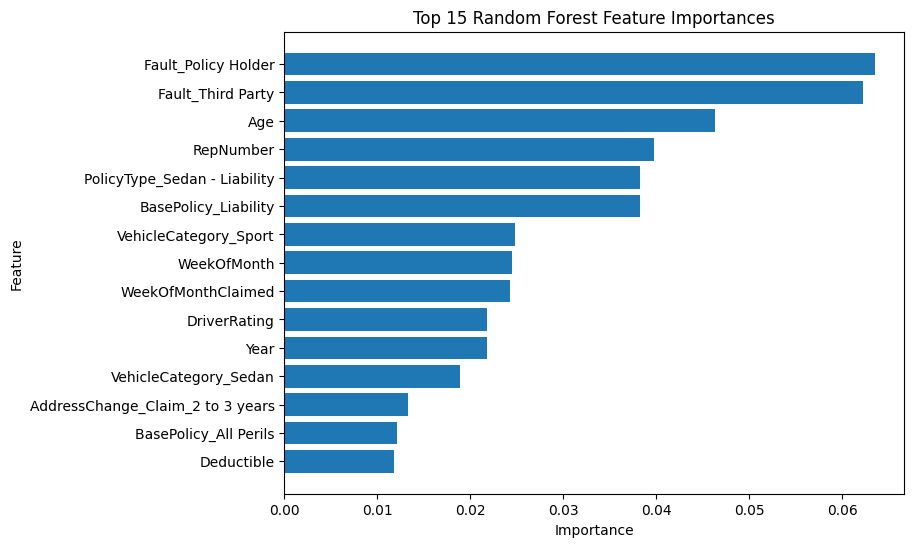


Top 20 Mutual Information Features:
                               Feature     Score  Selected
83        PolicyType_Sedan - Liability  0.020676      True
79                 Fault_Policy Holder  0.015917      True
151               BasePolicy_Liability  0.015829      True
91               VehicleCategory_Sport  0.013189      True
80                   Fault_Third Party  0.011164      True
90               VehicleCategory_Sedan  0.010565      True
149              BasePolicy_All Perils  0.009406      True
102  Days_Policy_Accident_more than 30  0.005383      True
133                 AgentType_External  0.004672      True
109          PastNumberOfClaims_2 to 4  0.004612      True
28                  DayOfWeek_Thursday  0.004584      True
93         VehiclePrice_20000 to 29000  0.004423      True
111            PastNumberOfClaims_none  0.003940      True
70                    MonthClaimed_Oct  0.003913      True
142      AddressChange_Claim_no change  0.003765      True
129               P

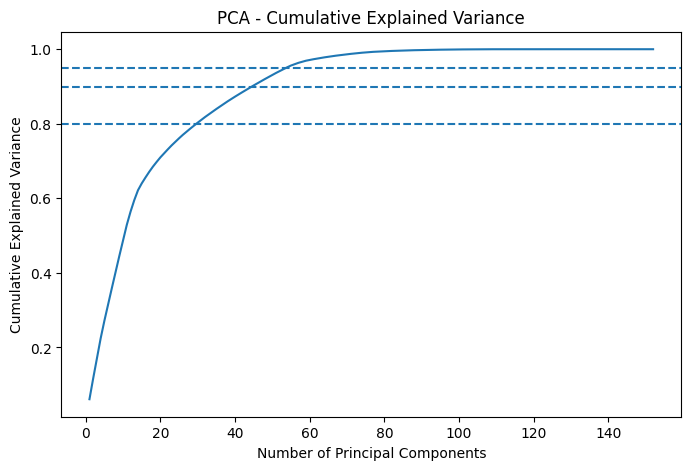

In [19]:
# =========================
# 5. PREPARE FEATURES FOR MODELING
# =========================
X = df_fe.drop(columns=[target])
y = df_fe[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("\nCategorical columns:", cat_cols)
print("\nNumeric columns:", num_cols)

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ]
)

# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 7. MODEL-BASED FEATURE IMPORTANCE
# =========================
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("\nRandom Forest Metrics:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# Get feature names after preprocessing
ohe = rf_pipeline.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
feature_names = num_cols + ohe.get_feature_names_out(cat_cols).tolist()

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(importance_df.head(20))

plt.figure(figsize=(8, 6))
top15 = importance_df.head(15).sort_values("Importance")
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# =========================
# 8. FEATURE SELECTION (FILTER METHOD)
# =========================
X_transformed = preprocess.fit_transform(X)

# Convert to dense only if needed
if hasattr(X_transformed, "toarray"):
    X_dense = X_transformed.toarray()
else:
    X_dense = X_transformed

selector = SelectKBest(score_func=mutual_info_classif, k=20)
selector.fit(X_dense, y)

selected_df = pd.DataFrame({
    "Feature": feature_names,
    "Score": selector.scores_,
    "Selected": selector.get_support()
}).sort_values("Score", ascending=False)

print("\nTop 20 Mutual Information Features:")
print(selected_df.head(20))

# =========================
# 9. PCA
# =========================
pca = PCA()
pca.fit(X_dense)

cum_var = np.cumsum(pca.explained_variance_ratio_)

for threshold in [0.80, 0.90, 0.95]:
    n_components = np.argmax(cum_var >= threshold) + 1
    print(f"Components needed for {int(threshold*100)}% variance: {n_components}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var)
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.show()

Original shape: (15420, 33)
Cleaned shape: (15420, 32)
Remaining Age = 0: 0
Remaining missing Age: 0
Feature-engineered shape: (15420, 37)

Categorical columns: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Numeric columns: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible', 'DriverRating', 'Year', 'HasPoliceReport', 'HasWitness', 'HighVehiclePrice', 'RecentAddressChange', 'ShortPolicyToAccident']

Train shape: (12336, 36)
Test shape : (3084, 36)

Training: Logistic Regression
Accuracy : 0.6433
Precision: 0.1319
Recall   : 0.8865
F1-score : 0.2297
ROC-AUC  : 0.8063

Confusion Matrix:
[[1820 1079]
 [  21  164]]

Classific

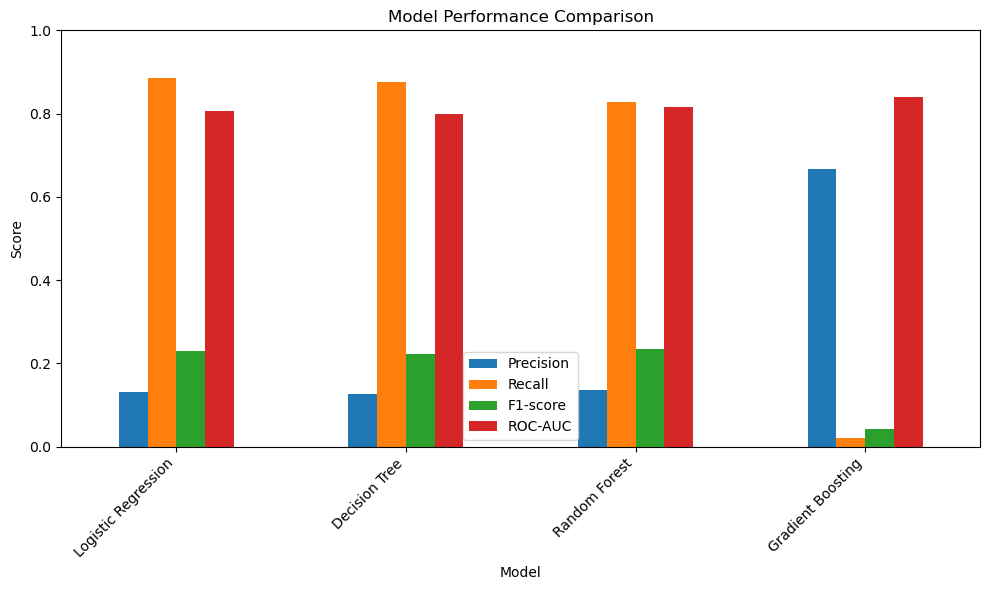


Best model based on Recall, ROC-AUC, and F1-score priority:
Logistic Regression


In [6]:
# Step 4: Model Implementation and Comparison

# =========================
# STEP 4: MODEL IMPLEMENTATION
# =========================

import os
import joblib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("fraud_oracle.csv")
print("Original shape:", df.shape)

# =========================
# 2. CLEAN DATA
# =========================
df_clean = df.copy()

# Recode invalid placeholders
df_clean["DayOfWeekClaimed"] = df_clean["DayOfWeekClaimed"].replace("0", "Unknown")
df_clean["MonthClaimed"] = df_clean["MonthClaimed"].replace("0", "Unknown")

# Keep "none" as category for these fields
# No replacement needed:
# df_clean["Days_Policy_Accident"]
# df_clean["Days_Policy_Claim"]

# Treat Age = 0 as invalid
df_clean["Age"] = df_clean["Age"].replace(0, np.nan)

# Impute Age using AgeOfPolicyHolder midpoint
age_band_midpoint = {
    "16 to 17": 16.5,
    "18 to 20": 19,
    "21 to 25": 23,
    "26 to 30": 28,
    "31 to 35": 33,
    "36 to 40": 38,
    "41 to 50": 45.5,
    "51 to 65": 58,
    "over 65": 70
}

df_clean["Age"] = df_clean.apply(
    lambda row: age_band_midpoint.get(row["AgeOfPolicyHolder"], np.nan)
    if pd.isna(row["Age"]) else row["Age"],
    axis=1
)

# Fallback median imputation
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Drop PolicyNumber because it is just an ID
df_clean = df_clean.drop(columns=["PolicyNumber"])

print("Cleaned shape:", df_clean.shape)
print("Remaining Age = 0:", (df_clean["Age"] == 0).sum())
print("Remaining missing Age:", df_clean["Age"].isna().sum())

# =========================
# 3. FEATURE ENGINEERING
# =========================
df_fe = df_clean.copy()

df_fe["HasPoliceReport"] = df_fe["PoliceReportFiled"].map({"Yes": 1, "No": 0})
df_fe["HasWitness"] = df_fe["WitnessPresent"].map({"Yes": 1, "No": 0})

high_price_bands = ["60000 to 69000", "more than 69000"]
df_fe["HighVehiclePrice"] = df_fe["VehiclePrice"].isin(high_price_bands).astype(int)

recent_address_bands = ["under 6 months", "1 year"]
df_fe["RecentAddressChange"] = df_fe["AddressChange_Claim"].isin(recent_address_bands).astype(int)

short_policy_accident_bands = ["1 to 7", "8 to 15", "15 to 30"]
df_fe["ShortPolicyToAccident"] = df_fe["Days_Policy_Accident"].isin(short_policy_accident_bands).astype(int)

print("Feature-engineered shape:", df_fe.shape)

# =========================
# 4. DEFINE FEATURES / TARGET
# =========================
target = "FraudFound_P"

X = df_fe.drop(columns=[target])
y = df_fe[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("\nCategorical columns:", cat_cols)
print("\nNumeric columns:", num_cols)

# =========================
# 5. PREPROCESSING
# =========================
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ]
)

# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# =========================
# 7. DEFINE MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# =========================
# 8. TRAIN, EVALUATE, SAVE
# =========================
os.makedirs("models", exist_ok=True)

results = []
trained_pipelines = {}

for model_name, model in models.items():
    print("\n" + "="*60)
    print(f"Training: {model_name}")
    print("="*60)

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    # Predict probabilities if available
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    trained_pipelines[model_name] = pipe

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4) if not np.isnan(roc_auc) else "N/A")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Save model
    safe_name = model_name.lower().replace(" ", "_")
    model_path = f"models/{safe_name}.pkl"
    joblib.dump(pipe, model_path)
    print(f"Saved model to: {model_path}")

# =========================
# 9. MODEL COMPARISON TABLE
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["Recall", "ROC-AUC", "F1-score"], ascending=False)

print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(results_df)

# Save metrics table
results_df.to_csv("models/model_comparison_metrics.csv", index=False)
print("\nSaved metrics table to: models/model_comparison_metrics.csv")

# =========================
# 10. VISUALIZE MODEL COMPARISON
# =========================
plot_df = results_df.set_index("Model")[["Precision", "Recall", "F1-score", "ROC-AUC"]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =========================
# 11. IDENTIFY BEST MODEL
# =========================
best_model_name = results_df.iloc[0]["Model"]
print("\nBest model based on Recall, ROC-AUC, and F1-score priority:")
print(best_model_name)

In [3]:
# =========================
# STEP 5: ETHICAL AI & BIAS AUDITING (SELF-CONTAINED)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("fraud_oracle.csv")
print("Original shape:", df.shape)

# =========================
# 2. CLEANING
# =========================
df_clean = df.copy()

# Recode invalid placeholders
df_clean["DayOfWeekClaimed"] = df_clean["DayOfWeekClaimed"].replace("0", "Unknown")
df_clean["MonthClaimed"] = df_clean["MonthClaimed"].replace("0", "Unknown")

# Keep "none" as category in these columns
# (no replacement needed)
# df_clean["Days_Policy_Accident"]
# df_clean["Days_Policy_Claim"]

# Treat Age = 0 as invalid
df_clean["Age"] = df_clean["Age"].replace(0, np.nan)

# Fill missing Age using AgeOfPolicyHolder midpoint
age_band_midpoint = {
    "16 to 17": 16.5,
    "18 to 20": 19,
    "21 to 25": 23,
    "26 to 30": 28,
    "31 to 35": 33,
    "36 to 40": 38,
    "41 to 50": 45.5,
    "51 to 65": 58,
    "over 65": 70
}

df_clean["Age_band_mid"] = df_clean["AgeOfPolicyHolder"].map(age_band_midpoint)
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age_band_mid"])
df_clean.drop(columns=["Age_band_mid"], inplace=True)

# =========================
# 3. FEATURE ENGINEERING
# =========================
df_fe = df_clean.copy()

df_fe["HasPoliceReport"] = df_fe["PoliceReportFiled"].map({"Yes": 1, "No": 0})
df_fe["HasWitness"] = df_fe["WitnessPresent"].map({"Yes": 1, "No": 0})

high_price_bands = ["60000 to 69000", "more than 69000"]
df_fe["HighVehiclePrice"] = df_fe["VehiclePrice"].isin(high_price_bands).astype(int)

recent_address_bands = ["under 6 months", "1 year"]
df_fe["RecentAddressChange"] = df_fe["AddressChange_Claim"].isin(recent_address_bands).astype(int)

short_policy_accident_bands = ["1 to 7", "8 to 15", "15 to 30"]
df_fe["ShortPolicyToAccident"] = df_fe["Days_Policy_Accident"].isin(short_policy_accident_bands).astype(int)

# =========================
# 4. PREPARE FEATURES
# =========================
target = "FraudFound_P"

# IMPORTANT: drop PolicyNumber (ID-like feature)
X = df_fe.drop(columns=[target, "PolicyNumber"])
y = df_fe[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", len(cat_cols))
print("Numeric columns:", len(num_cols))

# =========================
# 5. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 6. PREPROCESSING + RANDOM FOREST
# =========================
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ]
)

rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1

    ))
])

rf_pipe.fit(X_train, y_train)

# Use this as the best model for Step 5
best_pipe = rf_pipe

# =========================
# 7. CREATE AUDIT DATAFRAME
# =========================
y_pred_rf = best_pipe.predict(X_test)
y_prob_rf = best_pipe.predict_proba(X_test)[:, 1]

audit_df = X_test.copy()
audit_df["Actual"] = y_test.values
audit_df["Predicted"] = y_pred_rf
audit_df["Predicted_Prob"] = y_prob_rf

print("\nAudit dataframe preview:")
print(audit_df.head())

Original shape: (15420, 33)
Categorical columns: 24
Numeric columns: 12

Audit dataframe preview:
      Month  WeekOfMonth  DayOfWeek       Make AccidentArea DayOfWeekClaimed  \
8922    Jul            1   Thursday  Chevrolet        Urban           Friday   
4274    Nov            2     Sunday     Toyota        Urban           Monday   
3408    Dec            4     Friday       Ford        Rural        Wednesday   
10675   Apr            1  Wednesday      Honda        Urban          Tuesday   
3285    Mar            2     Sunday       Ford        Urban           Monday   

      MonthClaimed  WeekOfMonthClaimed   Sex MaritalStatus  ...  Year  \
8922           Jul                   3  Male       Married  ...  1995   
4274           Nov                   3  Male        Single  ...  1994   
3408           Dec                   4  Male       Married  ...  1994   
10675          Apr                   3  Male        Single  ...  1995   
3285           Mar                   3  Male       Marri

Top 20 important features:
                              Feature  Importance
80                  Fault_Third Party    0.115930
79                Fault_Policy Holder    0.111729
151              BasePolicy_Liability    0.086701
83       PolicyType_Sedan - Liability    0.079477
91              VehicleCategory_Sport    0.055151
90              VehicleCategory_Sedan    0.034003
140  AddressChange_Claim_2 to 3 years    0.028126
2                                 Age    0.026736
149             BasePolicy_All Perils    0.023808
3                           RepNumber    0.017823
4                          Deductible    0.017207
150              BasePolicy_Collision    0.016265
142     AddressChange_Claim_no change    0.015969
81      PolicyType_Sedan - All Perils    0.015205
6                                Year    0.013305
82       PolicyType_Sedan - Collision    0.011532
1                  WeekOfMonthClaimed    0.011093
0                         WeekOfMonth    0.010528
5                      

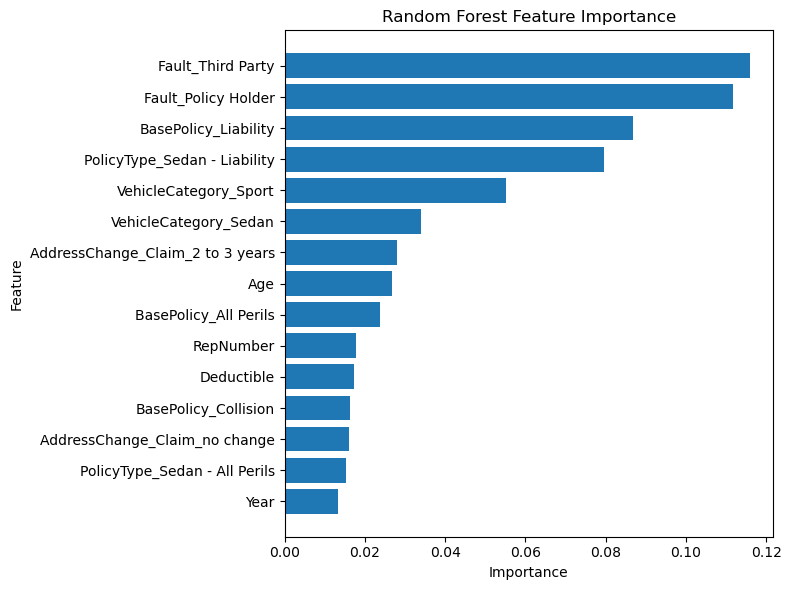

In [4]:
# =========================
# MODEL-BASED FEATURE IMPORTANCE
# =========================

# Get one-hot encoded feature names
ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

# Final transformed feature list
feature_names = num_cols + cat_feature_names

# Get Random Forest importances
rf_importances = best_pipe.named_steps["model"].feature_importances_

# Build importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

print("Top 20 important features:")
print(importance_df.head(20))

# Plot top 15
top15 = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [9]:
# =========================
# FAIRNESS METRICS BY GROUP
# =========================

def group_fairness_report(df, group_col, actual_col="Actual", pred_col="Predicted"):
    rows = []

    for group_value, group_data in df.groupby(group_col):
        actual = group_data[actual_col]
        pred = group_data[pred_col]

        # Positive prediction rate
        pos_rate = pred.mean()

        # Safe confusion matrix handling
        cm = confusion_matrix(actual, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan   # Recall / sensitivity
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        rows.append({
            "Group": group_value,
            "Count": len(group_data),
            "Positive Prediction Rate": pos_rate,
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "Precision": precision
        })

    result = pd.DataFrame(rows).sort_values("Count", ascending=False)
    return result

In [10]:
# =========================
# FAIRNESS AUDITS
# =========================

sex_report = group_fairness_report(audit_df, "Sex")
print("Fairness audit by Sex")
print(sex_report)

print("\n" + "="*70 + "\n")

age_report = group_fairness_report(audit_df, "AgeOfPolicyHolder")
print("Fairness audit by AgeOfPolicyHolder")
print(age_report)

print("\n" + "="*70 + "\n")

marital_report = group_fairness_report(audit_df, "MaritalStatus")
print("Fairness audit by MaritalStatus")
print(marital_report)

Fairness audit by Sex
    Group  Count  Positive Prediction Rate  True Positive Rate  \
1    Male   2583                  0.000387            0.006098   
0  Female    501                  0.000000            0.000000   

   False Positive Rate  Precision  
1                  0.0        1.0  
0                  0.0        NaN  


Fairness audit by AgeOfPolicyHolder
      Group  Count  Positive Prediction Rate  True Positive Rate  \
4  31 to 35   1125                  0.000000                 0.0   
5  36 to 40    791                  0.000000                 0.0   
6  41 to 50    581                  0.000000                 0.0   
7  51 to 65    280                  0.000000                 0.0   
3  26 to 30    112                  0.000000                 0.0   
8   over 65     94                  0.000000                 0.0   
0  16 to 17     69                  0.014493                 0.2   
2  21 to 25     29                  0.000000                 0.0   
1  18 to 20      3   

In [5]:
# =========================
# DISPARATE IMPACT
# =========================

def disparate_impact_table(report_df, rate_col="Positive Prediction Rate"):
    max_rate = report_df[rate_col].max()
    out = report_df.copy()
    out["Disparate Impact Ratio"] = out[rate_col] / max_rate
    return out.sort_values("Disparate Impact Ratio")

print("Sex disparate impact:")
print(disparate_impact_table(sex_report))

print("\n" + "="*70 + "\n")

print("AgeOfPolicyHolder disparate impact:")
print(disparate_impact_table(age_report))

print("\n" + "="*70 + "\n")

print("MaritalStatus disparate impact:")
print(disparate_impact_table(marital_report))

Sex disparate impact:


NameError: name 'sex_report' is not defined

In [ ]:
# Step 5: Ethical AI and Bias Auditing (Clean Final Version)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Load data
df = pd.read_csv("fraud_oracle.csv")

# Cleaning
df_clean = df.copy()
df_clean["DayOfWeekClaimed"] = df_clean["DayOfWeekClaimed"].replace("0", "Unknown")
df_clean["MonthClaimed"] = df_clean["MonthClaimed"].replace("0", "Unknown")
df_clean["Age"] = df_clean["Age"].replace(0, np.nan)

age_band_midpoint = {
    "16 to 17": 16.5,
    "18 to 20": 19,
    "21 to 25": 23,
    "26 to 30": 28,
    "31 to 35": 33,
    "36 to 40": 38,
    "41 to 50": 45.5,
    "51 to 65": 58,
    "over 65": 70
}

df_clean["Age_band_mid"] = df_clean["AgeOfPolicyHolder"].map(age_band_midpoint)
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age_band_mid"])
df_clean.drop(columns=["Age_band_mid"], inplace=True)

# Feature engineering
df_fe = df_clean.copy()
df_fe["HasPoliceReport"] = df_fe["PoliceReportFiled"].map({"Yes": 1, "No": 0})
df_fe["HasWitness"] = df_fe["WitnessPresent"].map({"Yes": 1, "No": 0})

high_price_bands = ["60000 to 69000", "more than 69000"]
df_fe["HighVehiclePrice"] = df_fe["VehiclePrice"].isin(high_price_bands).astype(int)

recent_address_bands = ["under 6 months", "1 year"]
df_fe["RecentAddressChange"] = df_fe["AddressChange_Claim"].isin(recent_address_bands).astype(int)

short_policy_accident_bands = ["1 to 7", "8 to 15", "15 to 30"]
df_fe["ShortPolicyToAccident"] = df_fe["Days_Policy_Accident"].isin(short_policy_accident_bands).astype(int)

# Prepare features
target = "FraudFound_P"
X = df_fe.drop(columns=[target, "PolicyNumber"])
y = df_fe[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ]
)

# Random Forest matching Step 4
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

best_pipe = rf_pipe

y_pred_rf = best_pipe.predict(X_test)
y_prob_rf = best_pipe.predict_proba(X_test)[:, 1]

audit_df = X_test.copy()
audit_df["Actual"] = y_test.values
audit_df["Predicted"] = y_pred_rf
audit_df["Predicted_Prob"] = y_prob_rf

print("Step 5 model is ready.")
print(audit_df[["Actual", "Predicted", "Predicted_Prob"]].head())

Step 5 model is ready.
       Actual  Predicted  Predicted_Prob
8922        0          0        0.058040
4274        0          0        0.461804
3408        0          0        0.146390
10675       0          1        0.562825
3285        0          0        0.100980


Top 20 important features:
                              Feature  Importance
80                  Fault_Third Party    0.115930
79                Fault_Policy Holder    0.111729
151              BasePolicy_Liability    0.086701
83       PolicyType_Sedan - Liability    0.079477
91              VehicleCategory_Sport    0.055151
90              VehicleCategory_Sedan    0.034003
140  AddressChange_Claim_2 to 3 years    0.028126
2                                 Age    0.026736
149             BasePolicy_All Perils    0.023808
3                           RepNumber    0.017823
4                          Deductible    0.017207
150              BasePolicy_Collision    0.016265
142     AddressChange_Claim_no change    0.015969
81      PolicyType_Sedan - All Perils    0.015205
6                                Year    0.013305
82       PolicyType_Sedan - Collision    0.011532
1                  WeekOfMonthClaimed    0.011093
0                         WeekOfMonth    0.010528
5                      

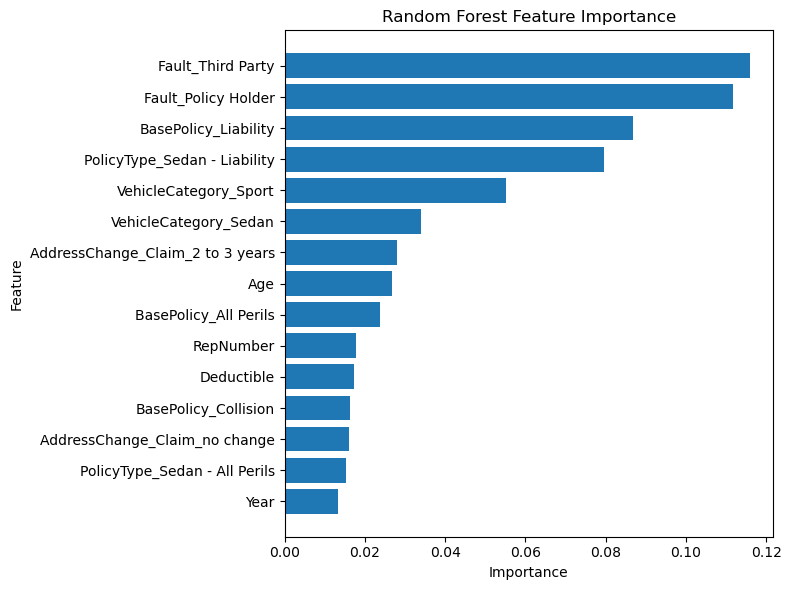

In [7]:
# MODEL-BASED FEATURE IMPORTANCE

ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_cols + cat_feature_names

rf_importances = best_pipe.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

print("Top 20 important features:")
print(importance_df.head(20))

top15 = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [8]:
# FAIRNESS HELPER FUNCTION

def group_fairness_report(df, group_col, actual_col="Actual", pred_col="Predicted"):
    rows = []

    for group_value, group_data in df.groupby(group_col):
        actual = group_data[actual_col]
        pred = group_data[pred_col]

        pos_rate = pred.mean()

        cm = confusion_matrix(actual, pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        rows.append({
            "Group": group_value,
            "Count": len(group_data),
            "Positive Prediction Rate": pos_rate,
            "True Positive Rate": tpr,
            "False Positive Rate": fpr,
            "Precision": precision
        })

    result = pd.DataFrame(rows).sort_values("Count", ascending=False)
    return result

In [9]:
# FAIRNESS REPORTS

sex_report = group_fairness_report(audit_df, "Sex")
print("Fairness audit by Sex")
print(sex_report)

print("\n" + "="*70 + "\n")

age_report = group_fairness_report(audit_df, "AgeOfPolicyHolder")
print("Fairness audit by AgeOfPolicyHolder")
print(age_report)

print("\n" + "="*70 + "\n")

marital_report = group_fairness_report(audit_df, "MaritalStatus")
print("Fairness audit by MaritalStatus")
print(marital_report)

Fairness audit by Sex
    Group  Count  Positive Prediction Rate  True Positive Rate  \
1    Male   2583                  0.382114            0.853659   
0  Female    501                  0.261477            0.619048   

   False Positive Rate  Precision  
1             0.350145   0.141844  
0             0.245833   0.099237  


Fairness audit by AgeOfPolicyHolder
      Group  Count  Positive Prediction Rate  True Positive Rate  \
4  31 to 35   1125                  0.380444            0.873418   
5  36 to 40    791                  0.348925            0.780488   
6  41 to 50    581                  0.347676            0.705882   
7  51 to 65    280                  0.350000            0.916667   
3  26 to 30    112                  0.330357            0.600000   
8   over 65     94                  0.340426            1.000000   
0  16 to 17     69                  0.391304            1.000000   
2  21 to 25     29                  0.551724            1.000000   
1  18 to 20      3   

In [10]:
# DISPARATE IMPACT

def disparate_impact_table(report_df, rate_col="Positive Prediction Rate"):
    max_rate = report_df[rate_col].max()
    out = report_df.copy()
    out["Disparate Impact Ratio"] = out[rate_col] / max_rate
    return out.sort_values("Disparate Impact Ratio")

print("Sex disparate impact:")
print(disparate_impact_table(sex_report))

print("\n" + "="*70 + "\n")

print("AgeOfPolicyHolder disparate impact:")
print(disparate_impact_table(age_report))

print("\n" + "="*70 + "\n")

print("MaritalStatus disparate impact:")
print(disparate_impact_table(marital_report))

Sex disparate impact:
    Group  Count  Positive Prediction Rate  True Positive Rate  \
0  Female    501                  0.261477            0.619048   
1    Male   2583                  0.382114            0.853659   

   False Positive Rate  Precision  Disparate Impact Ratio  
0             0.245833   0.099237                0.684291  
1             0.350145   0.141844                1.000000  


AgeOfPolicyHolder disparate impact:
      Group  Count  Positive Prediction Rate  True Positive Rate  \
3  26 to 30    112                  0.330357            0.600000   
8   over 65     94                  0.340426            1.000000   
6  41 to 50    581                  0.347676            0.705882   
5  36 to 40    791                  0.348925            0.780488   
7  51 to 65    280                  0.350000            0.916667   
4  31 to 35   1125                  0.380444            0.873418   
0  16 to 17     69                  0.391304            1.000000   
2  21 to 25     2

In [ ]:
## Step 5 Additional Mitigation Test

Because **Age**, **RepNumber**, and **AddressChange_Claim** may introduce fairness, proxy, or process-bias risks, an additional **Random Forest** model is tested after removing these variables.

The purpose of this extra step is to check whether model performance can remain useful **while reducing potential ethical risk**.

This strengthens the project by moving beyond **bias identification** into **mitigation-oriented responsible AI testing**.

In [3]:
# STEP 5 HELPER: detect the main dataframe variable safely

possible_df_names = ['df', 'data', 'insurance_df', 'fraud_df', 'claims_df', 'dataset']

main_df = None
main_df_name = None

for name in possible_df_names:
    if name in globals():
        obj = globals()[name]
        try:
            # Check if it behaves like a pandas DataFrame
            if hasattr(obj, 'columns') and hasattr(obj, 'shape'):
                main_df = obj
                main_df_name = name
                break
        except:
            pass

if main_df is not None:
    print(f"Detected dataframe variable: {main_df_name}")
    print("Shape:", main_df.shape)
    print("First 10 columns:", main_df.columns.tolist()[:10])
else:
    print("No dataframe detected automatically.")
    print("If this happens, run: print(globals().keys())")

No dataframe detected automatically.
If this happens, run: print(globals().keys())


In [4]:
# STEP 5 HELPER: check important columns

if main_df is not None:
    print("All columns:")
    print(main_df.columns.tolist())
    
    required_cols = ['FraudFound_P', 'PolicyNumber', 'Age', 'RepNumber', 'AddressChange_Claim', 'Sex']
    print("\nChecking required columns:")
    
    for col in required_cols:
        print(f"{col}: {'FOUND' if col in main_df.columns else 'NOT FOUND'}")

In [5]:
# Create mitigated dataset by removing risky columns
# We use errors='ignore' so it won't crash if PolicyNumber was already removed earlier

X_mitigated = main_df.drop(
    columns=['FraudFound_P', 'PolicyNumber', 'Age', 'RepNumber', 'AddressChange_Claim'],
    errors='ignore'
)

y_mitigated = main_df['FraudFound_P']

print("Mitigated feature matrix shape:", X_mitigated.shape)
print("Target shape:", y_mitigated.shape)
print("Remaining columns (first 10):", X_mitigated.columns.tolist()[:10])

AttributeError: 'NoneType' object has no attribute 'drop'

In [6]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', '_i3', 'possible_df_names', 'main_df', 'main_df_name', 'name', '_i4', '_i5', '_i6'])


In [10]:
for var_name in list(globals().keys()):
    if not var_name.startswith("_"):
        print(var_name)

In
Out
get_ipython
exit
quit
open
possible_df_names
main_df
main_df_name
name


In [15]:
import pandas as pd

for var_name, var_value in list(globals().items()):
    try:
        if isinstance(var_value, pd.DataFrame):
            print(var_name, var_value.shape)
    except:
        pass

In [17]:
import pandas as pd

for var_name, var_value in list(globals().items()):
    try:
        if isinstance(var_value, pd.DataFrame):
            print(var_name, var_value.shape)
    except:
        pass

df (15420, 33)
df_clean (15420, 32)


In [20]:
# STEP 5 MITIGATION: create mitigated dataset by removing risky columns from df_clean

X_mitigated = df_clean.drop(
    columns=['FraudFound_P', 'Age', 'RepNumber', 'AddressChange_Claim'],
    errors='ignore'
)

y_mitigated = df_clean['FraudFound_P']

print("Mitigated feature matrix shape:", X_mitigated.shape)
print("Target shape:", y_mitigated.shape)
print("Remaining columns (first 10):", X_mitigated.columns.tolist()[:10])

Mitigated feature matrix shape: (15420, 28)
Target shape: (15420,)
Remaining columns (first 10): ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus']


In [21]:
# STEP 5 MITIGATION: split data, train Random Forest, and evaluate

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mitigated,
    y_mitigated,
    test_size=0.2,
    random_state=42,
    stratify=y_mitigated
)

# train mitigated Random Forest
rf_mitigated = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_mitigated.fit(X_train_m, y_train_m)

# predictions
y_pred_m = rf_mitigated.predict(X_test_m)
y_prob_m = rf_mitigated.predict_proba(X_test_m)[:, 1]

# metrics
mit_accuracy = accuracy_score(y_test_m, y_pred_m)
mit_precision = precision_score(y_test_m, y_pred_m, zero_division=0)
mit_recall = recall_score(y_test_m, y_pred_m, zero_division=0)
mit_f1 = f1_score(y_test_m, y_pred_m, zero_division=0)
mit_roc_auc = roc_auc_score(y_test_m, y_prob_m)

print("Mitigated Random Forest Performance")
print("Accuracy :", round(mit_accuracy, 4))
print("Precision:", round(mit_precision, 4))
print("Recall   :", round(mit_recall, 4))
print("F1 Score :", round(mit_f1, 4))
print("ROC-AUC  :", round(mit_roc_auc, 4))

ValueError: could not convert string to float: 'Sep'

In [22]:
# STEP 5 MITIGATION: encode text columns, split data, train Random Forest, evaluate

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# convert categorical columns into numeric dummy variables
X_mitigated_encoded = pd.get_dummies(X_mitigated, drop_first=True)

print("Encoded mitigated feature matrix shape:", X_mitigated_encoded.shape)

# split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mitigated_encoded,
    y_mitigated,
    test_size=0.2,
    random_state=42,
    stratify=y_mitigated
)

# train mitigated Random Forest
rf_mitigated = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_mitigated.fit(X_train_m, y_train_m)

# predictions
y_pred_m = rf_mitigated.predict(X_test_m)
y_prob_m = rf_mitigated.predict_proba(X_test_m)[:, 1]

# metrics
mit_accuracy = accuracy_score(y_test_m, y_pred_m)
mit_precision = precision_score(y_test_m, y_pred_m, zero_division=0)
mit_recall = recall_score(y_test_m, y_pred_m, zero_division=0)
mit_f1 = f1_score(y_test_m, y_pred_m, zero_division=0)
mit_roc_auc = roc_auc_score(y_test_m, y_prob_m)

print("Mitigated Random Forest Performance")
print("Accuracy :", round(mit_accuracy, 4))
print("Precision:", round(mit_precision, 4))
print("Recall   :", round(mit_recall, 4))
print("F1 Score :", round(mit_f1, 4))
print("ROC-AUC  :", round(mit_roc_auc, 4))

Encoded mitigated feature matrix shape: (15420, 117)
Mitigated Random Forest Performance
Accuracy : 0.9403
Precision: 1.0
Recall   : 0.0054
F1 Score : 0.0108
ROC-AUC  : 0.8167


Confusion Matrix:
[[2899    0]
 [ 184    1]]


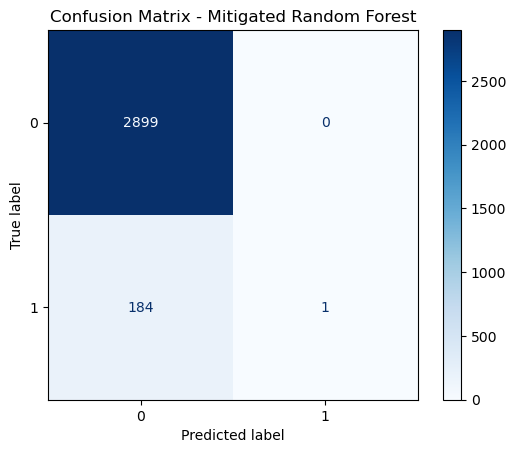

In [23]:
# STEP 5 VALIDATION 1: Confusion matrix for mitigated model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_mitigated = confusion_matrix(y_test_m, y_pred_m)

print("Confusion Matrix:")
print(cm_mitigated)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mitigated)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Mitigated Random Forest")
plt.show()

In [24]:
# STEP 5 VALIDATION 2: Count predicted fraud cases

predicted_fraud_count = (y_pred_m == 1).sum()
actual_fraud_count = (y_test_m == 1).sum()
correct_fraud_predictions = ((y_pred_m == 1) & (y_test_m == 1)).sum()

print("Actual fraud cases in test set:", actual_fraud_count)
print("Predicted fraud cases by mitigated model:", predicted_fraud_count)
print("Correct fraud predictions:", correct_fraud_predictions)

if predicted_fraud_count > 0:
    precision_manual = correct_fraud_predictions / predicted_fraud_count
    print("Manual precision check:", round(precision_manual, 4))
else:
    print("Manual precision check: No positive predictions were made.")

Actual fraud cases in test set: 185
Predicted fraud cases by mitigated model: 1
Correct fraud predictions: 1
Manual precision check: 1.0


In [25]:
# STEP 5 VALIDATION 3: Quick train vs test check

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train predictions
y_train_pred_m = rf_mitigated.predict(X_train_m)
y_train_prob_m = rf_mitigated.predict_proba(X_train_m)[:, 1]

# Train metrics
train_accuracy = accuracy_score(y_train_m, y_train_pred_m)
train_precision = precision_score(y_train_m, y_train_pred_m, zero_division=0)
train_recall = recall_score(y_train_m, y_train_pred_m, zero_division=0)
train_f1 = f1_score(y_train_m, y_train_pred_m, zero_division=0)
train_roc_auc = roc_auc_score(y_train_m, y_train_prob_m)

# Test metrics already calculated earlier
print("TRAIN METRICS")
print("Accuracy :", round(train_accuracy, 4))
print("Precision:", round(train_precision, 4))
print("Recall   :", round(train_recall, 4))
print("F1 Score :", round(train_f1, 4))
print("ROC-AUC  :", round(train_roc_auc, 4))

print("\nTEST METRICS")
print("Accuracy :", round(mit_accuracy, 4))
print("Precision:", round(mit_precision, 4))
print("Recall   :", round(mit_recall, 4))
print("F1 Score :", round(mit_f1, 4))
print("ROC-AUC  :", round(mit_roc_auc, 4))

TRAIN METRICS
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

TEST METRICS
Accuracy : 0.9403
Precision: 1.0
Recall   : 0.0054
F1 Score : 0.0108
ROC-AUC  : 0.8167


In [26]:
# STEP 5A - Baseline Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Baseline model
dt_baseline = DecisionTreeClassifier(random_state=42)

# Train
dt_baseline.fit(X_train, y_train)

# Predict
y_pred_dt_base = dt_baseline.predict(X_test)
y_prob_dt_base = dt_baseline.predict_proba(X_test)[:, 1]

# Metrics
acc_dt_base = accuracy_score(y_test, y_pred_dt_base)
prec_dt_base = precision_score(y_test, y_pred_dt_base, zero_division=0)
rec_dt_base = recall_score(y_test, y_pred_dt_base, zero_division=0)
f1_dt_base = f1_score(y_test, y_pred_dt_base, zero_division=0)
roc_dt_base = roc_auc_score(y_test, y_prob_dt_base)

print("=== Baseline Decision Tree Results ===")
print(f"Accuracy : {acc_dt_base:.4f}")
print(f"Precision: {prec_dt_base:.4f}")
print(f"Recall   : {rec_dt_base:.4f}")
print(f"F1 Score : {f1_dt_base:.4f}")
print(f"ROC-AUC  : {roc_dt_base:.4f}")

cm_dt_base = confusion_matrix(y_test, y_pred_dt_base)
print("\nConfusion Matrix:")
print(cm_dt_base)

NameError: name 'X_train' is not defined

In [28]:
# Check what train/test variable names already exist
print([name for name in globals() if 'train' in name.lower() or 'test' in name.lower()])

['train_test_split', 'X_train_m', 'X_test_m', 'y_train_m', 'y_test_m', 'y_train_pred_m', 'y_train_prob_m', 'train_accuracy', 'train_precision', 'train_recall', 'train_f1', 'train_roc_auc']


In [29]:
# STEP 5A - Baseline Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Baseline model
dt_baseline = DecisionTreeClassifier(random_state=42)

# Train
dt_baseline.fit(X_train_m, y_train_m)

# Predict
y_pred_dt_base = dt_baseline.predict(X_test_m)
y_prob_dt_base = dt_baseline.predict_proba(X_test_m)[:, 1]

# Metrics
acc_dt_base = accuracy_score(y_test_m, y_pred_dt_base)
prec_dt_base = precision_score(y_test_m, y_pred_dt_base, zero_division=0)
rec_dt_base = recall_score(y_test_m, y_pred_dt_base, zero_division=0)
f1_dt_base = f1_score(y_test_m, y_pred_dt_base, zero_division=0)
roc_dt_base = roc_auc_score(y_test_m, y_prob_dt_base)

print("=== Baseline Decision Tree Results ===")
print(f"Accuracy : {acc_dt_base:.4f}")
print(f"Precision: {prec_dt_base:.4f}")
print(f"Recall   : {rec_dt_base:.4f}")
print(f"F1 Score : {f1_dt_base:.4f}")
print(f"ROC-AUC  : {roc_dt_base:.4f}")

cm_dt_base = confusion_matrix(y_test_m, y_pred_dt_base)
print("\nConfusion Matrix:")
print(cm_dt_base)

=== Baseline Decision Tree Results ===
Accuracy : 0.9095
Precision: 0.2330
Recall   : 0.2216
F1 Score : 0.2271
ROC-AUC  : 0.5875

Confusion Matrix:
[[2764  135]
 [ 144   41]]


In [30]:
# STEP 5B - FAST Tuned Decision Tree

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid_dt_fast = {
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'class_weight': [None, 'balanced']
}

dt_for_tuning = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    estimator=dt_for_tuning,
    param_grid=param_grid_dt_fast,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_m, y_train_m)

best_dt = grid_dt.best_estimator_

print("=== Best Decision Tree Parameters ===")
print(grid_dt.best_params_)
print(f"Best CV F1 Score: {grid_dt.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
=== Best Decision Tree Parameters ===
{'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 Score: 0.2303


In [32]:
# STEP 5C - Evaluate Tuned Decision Tree on Test Set

y_pred_dt_tuned = best_dt.predict(X_test_m)
y_prob_dt_tuned = best_dt.predict_proba(X_test_m)[:, 1]

acc_dt_tuned = accuracy_score(y_test_m, y_pred_dt_tuned)
prec_dt_tuned = precision_score(y_test_m, y_pred_dt_tuned, zero_division=0)
rec_dt_tuned = recall_score(y_test_m, y_pred_dt_tuned, zero_division=0)
f1_dt_tuned = f1_score(y_test_m, y_pred_dt_tuned, zero_division=0)
roc_dt_tuned = roc_auc_score(y_test_m, y_prob_dt_tuned)

print("=== Tuned Decision Tree Results ===")
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"Precision: {prec_dt_tuned:.4f}")
print(f"Recall   : {rec_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"ROC-AUC  : {roc_dt_tuned:.4f}")

cm_dt_tuned = confusion_matrix(y_test_m, y_pred_dt_tuned)
print("\nConfusion Matrix:")
print(cm_dt_tuned)

=== Tuned Decision Tree Results ===
Accuracy : 0.6378
Precision: 0.1319
Recall   : 0.9027
F1 Score : 0.2302
ROC-AUC  : 0.7963

Confusion Matrix:
[[1800 1099]
 [  18  167]]


In [33]:
# STEP 5D - Compare Baseline vs Tuned Decision Tree

import pandas as pd

dt_comparison = pd.DataFrame({
    'Model': ['Baseline Decision Tree', 'Tuned Decision Tree'],
    'Accuracy': [acc_dt_base, acc_dt_tuned],
    'Precision': [prec_dt_base, prec_dt_tuned],
    'Recall': [rec_dt_base, rec_dt_tuned],
    'F1 Score': [f1_dt_base, f1_dt_tuned],
    'ROC-AUC': [roc_dt_base, roc_dt_tuned]
})

dt_comparison = dt_comparison.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("=== Decision Tree Model Comparison ===")
display(dt_comparison)

=== Decision Tree Model Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Decision Tree,0.637808,0.131912,0.902703,0.230186,0.796271
1,Baseline Decision Tree,0.909533,0.232955,0.221622,0.227147,0.587527
